In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["Order Date", "Ship Date"]
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Shipping Days,Year,Month,Month Name,Quarter,Day Name,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,3,2016,11,November,4,Tuesday,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,3,2016,11,November,4,Tuesday,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,4,2016,6,June,2,Sunday,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,7,2015,10,October,4,Sunday,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,7,2015,10,October,4,Sunday,11.25


# Customers Analysis
🎯 Objective

Business ye samajhna chahta hai:

Kaunse customers sabse valuable hain?
Kis segment se sabse zyada revenue aata hai?
Kis state aur city me customers zyada hain?
Loyal customers kaun hain?

# Total Customers (KPI)
How many unique customers are there?

In [4]:
total_customers = df["Customer ID"].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


## Business Question

How many unique customers are there?

## Why is this important?

- It helps understand the size of the customer base.
- It serves as a key business KPI.
- It is useful for measuring customer growth over time.
- It supports customer retention and acquisition analysis.

# 2. Top 10 Customers by Sales
Which customers generated the highest sales?


In [5]:
top_customers  = (df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10).reset_index())
top_customers 

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


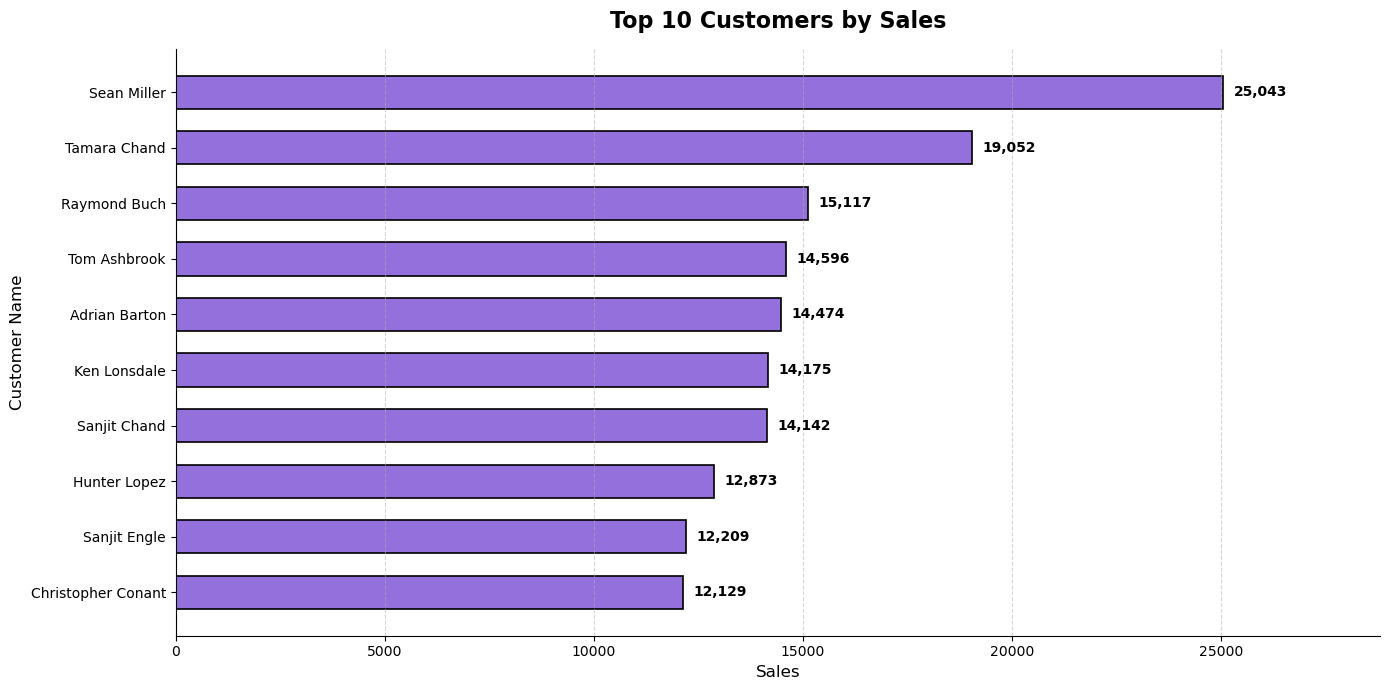

In [97]:

plt.figure(figsize=(14,7))

bars = plt.barh(top_customers["Customer Name"], top_customers["Sales"],
         color="mediumpurple", edgecolor="black",
         linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Sales", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Sales", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x",linestyle="--", alpha=0.5)
plt.yticks(fontsize=10)

plt.xlim(0, top_customers["Sales"].max() * 1.15)

# Value labels
offset = top_customers["Sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_customers_sales.png",dpi=300, bbox_inches="tight"
)
plt.show()



Top 10 Customers by Sales

# Objective

Identify the customers contributing the highest sales.

# Business Value

Identify VIP customers.
Improve customer retention.
Design loyalty programs.
Increase repeat purchases.
Focus marketing on high-value customers.

# Visualization

# Horizontal Bar Chart

# Key Insight

Sean Miller is the highest revenue-generating customer, followed by Tamara Chand. These customers represent the business's most valuable customer segment and should be prioritized for retention strategies.

# Top 10 Customers by Profit
Which customers generated the highest profit?

In [14]:
top_customers_by_profit = (df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10).reset_index())
top_customers_by_profit

,Customer Name,Profit
0,Tamara Chand,8981.3239
1,Raymond Buch,6976.0959
2,Sanjit Chand,5757.4119
3,Hunter Lopez,5622.4292
4,Adrian Barton,5444.8055
5,Tom Ashbrook,4703.7883
6,Christopher Martinez,3899.8904
7,Keith Dawkins,3038.6254
8,Andy Reiter,2884.6208
9,Daniel Raglin,2869.0760


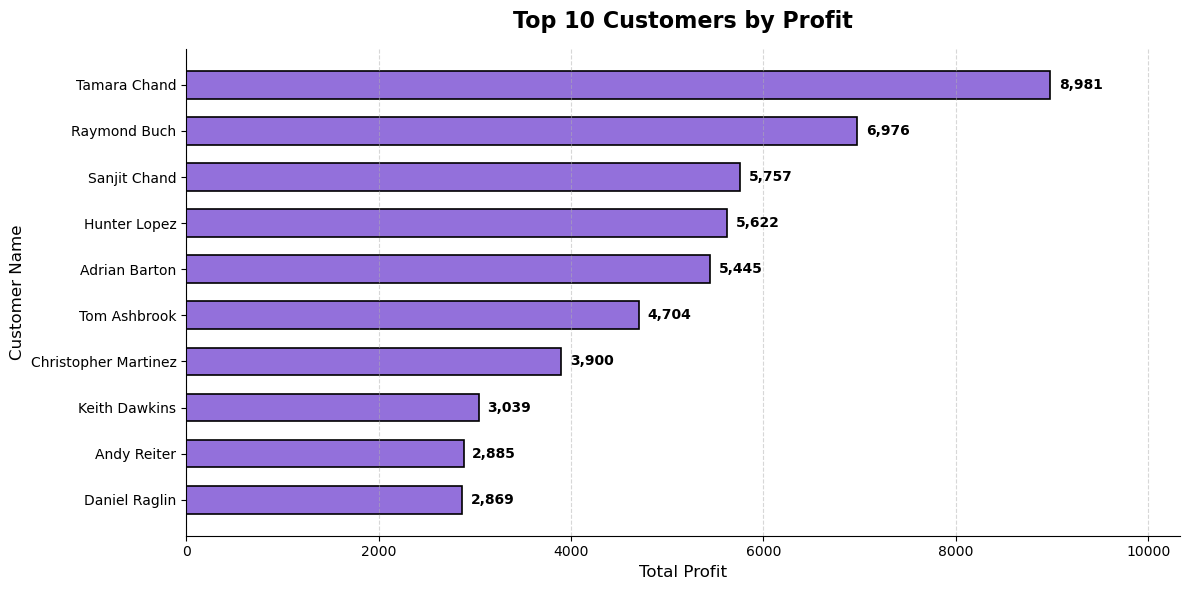

In [98]:
plt.figure(figsize=(12,6))

bars = plt.barh(top_customers_by_profit["Customer Name"], top_customers_by_profit["Profit"], color="mediumpurple", edgecolor="black", linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, top_customers_by_profit["Profit"].max() * 1.15)


offset = top_customers_by_profit["Profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "../visualizations/customers/top10_customers_profit.png",dpi=300, bbox_inches="tight"
)

plt.tight_layout()
plt.show()

# Top 10 Loss-Making Customers
Which customers generated the highest loss?

In [95]:
top10_loss_customers = (df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_loss_customers

,Customer Name,Profit
0,Cindy Stewart,-6626.3895
1,Grant Thornton,-4108.6589
2,Luke Foster,-3583.9770
3,Sharelle Roach,-3333.9144
4,Henry Goldwyn,-2797.9635
5,Nathan Cano,-2204.8072
6,Sean Braxton,-2082.7451
7,Sean Miller,-1980.7393
8,Christine Phan,-1850.3029
9,Natalie Fritzler,-1695.9714


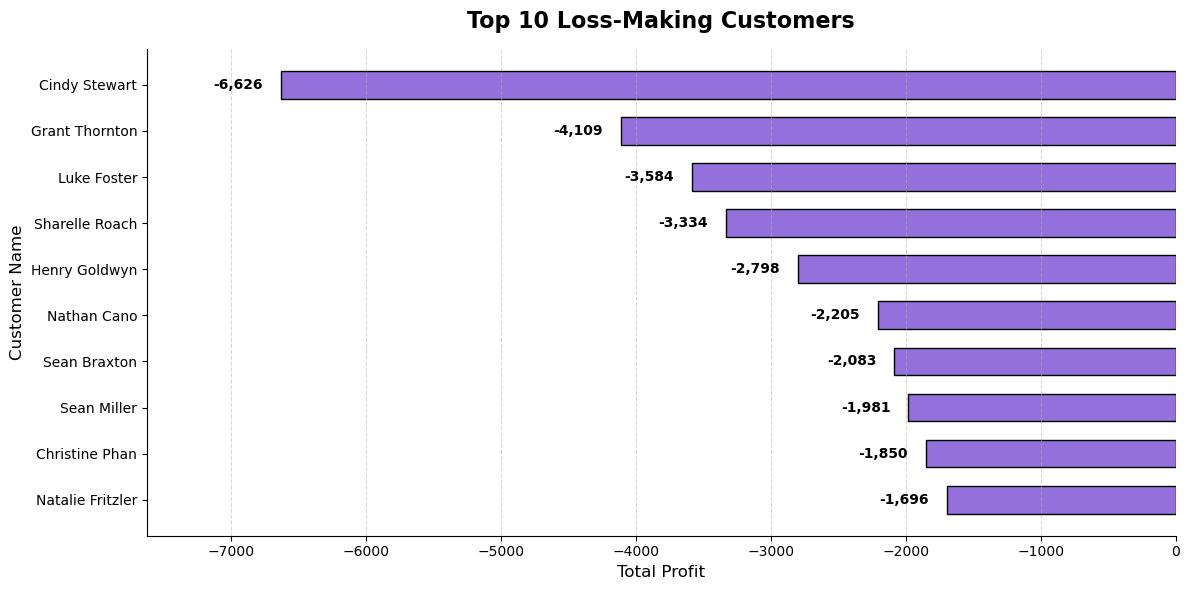

In [99]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_loss_customers["Customer Name"], top10_loss_customers["Profit"],
         color="mediumpurple",
         edgecolor="black",
         height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Loss-Making Customers", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit", fontsize=12)
plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

# Extra Space for labels
plt.xlim(top10_loss_customers["Profit"].min() * 1.15,0)

offset = abs(top10_loss_customers["Profit"].min()) * 0.02

for bar in bars:
    plt.text(
        bar.get_width() - offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="right",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_loss_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()